# Week 5 — ANOVA and Repeated Measures

## Contents

1. [Repeated-measures practical](#repeated-measures-practical)
2. [Advanced ANOVA mechanics](#advanced-anova)

The first part contains the main Week 5 practical material.

The final part contains **advanced/optional material** for students who
would like a deeper understanding of the statistical mechanics of ANOVA.

---


<a id="repeated-measures-practical"></a>

# Part I — Repeated-measures practical


# Notebook 5A — Practical: Repeated-measures ANOVA with IBL behaviour

**Quantitative Methods in Neuroscience · Master in Neuroscience · University of Geneva**  
**Responsible TA:** Caroline · **Contributing TA:** Maël

This is the **essential practical notebook**. It deliberately keeps the mathematics light and focuses on the analysis decisions students must make in a real repeated-measures experiment.

## By the end of the practical, you will be able to

1. identify the outcome, within-subject factor, and subject identifier;
2. transform trial-level data into one observation per mouse and condition;
3. visualize distributions while preserving the paired structure;
4. fit and interpret a repeated-measures ANOVA;
5. perform paired follow-up comparisons with Holm correction;
6. produce a final boxplot with corrected significance brackets;
7. write a concise scientific result.

## Suggested two-hour structure

| Time | Activity |
|---|---|
| 0–15 min | Scientific question and data structure |
| 15–40 min | Cleaning and grouping |
| 40–65 min | Boxplot and paired visualization |
| 65–95 min | Repeated-measures ANOVA |
| 95–115 min | Follow-up comparisons |
| 115–120 min | Write the result |

Difficulty tags follow the course convention: ⭐ essential, ⭐⭐ short extension, ⭐⭐⭐ optional challenge.


## 0 · Setup

Use the shared **Python (qmn)** kernel created in Week 1.

The IBL dataset was already prepared at the beginning of the course and is stored in:

```text
notebooks/data/ibl_2afc.csv.gz
```

Place this Week 5 notebook inside the course `notebooks/` folder, alongside Notebooks 1 and 2. The notebook does **not** install packages, contact OpenAlyx, or download the IBL data again.


In [1]:
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 50)

# Same relative-path convention used by the earlier course notebooks.
DATA_PATH = Path("data") / "ibl_2afc.csv.gz"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find data/ibl_2afc.csv.gz. "
        "Open this notebook from the QMN course notebooks/ folder and check "
        "that the Week 1 course data were downloaded or copied correctly."
    )

print("Using the shared course dataset:", DATA_PATH.resolve())


Using the shared course dataset: /home/carolinealves/Documents/QMN-subject/QMN_course_2026_with_Week5_v2/QMN_course_2026-main/notebooks/data/ibl_2afc.csv.gz


## 1 · Scientific question

Mice performed a visual decision-making task at several stimulus contrasts. Stronger contrast provides clearer visual evidence.

> **Question:** Does mean reaction time differ across low, medium, and high stimulus contrast when the same mice are measured in every condition?

The variables are:

| Statistical role | Dataset column |
|---|---|
| Subject identifier | `subject_id` |
| Within-subject factor | `contrast_level` |
| Dependent variable | mean `reaction_time_s` |

Because every mouse contributes to every contrast condition, the observations are paired by mouse.


### Exercise 1 — ⭐

Before running code, answer in one sentence: why would an analysis that treats all trials as independent overstate the amount of independent information?


In [ ]:
# Write your answer as a Python string.
answer_exercise_1 = 'The mouse, not the trial, is the independent experimental unit; trials from the same mouse are correlated.'
print(answer_exercise_1)


## 2 · Load and inspect the shared IBL course data

This is the **same full IBL behavioural dataset used across the course**, not a Week 5-specific copy. To keep memory use modest, we load only the columns required for this practical.

The file remains trial-level at this stage. Later, we will create one value per mouse and contrast condition for the repeated-measures analysis.


In [3]:
# Load only the variables needed for the Week 5 question.
columns_needed = [
    "subject_id",
    "phase",
    "signed_contrast",
    "no_go",
    "reaction_time_s",
    "correct",
]

trials = pd.read_csv(DATA_PATH, usecols=columns_needed)

print("Rows, columns loaded:", trials.shape)
print("Mice:", trials["subject_id"].nunique())
display(trials.head())


Rows, columns loaded: (694182, 6)
Mice: 30


,subject_id,phase,signed_contrast,correct,no_go,reaction_time_s
0,CSHL051,training,0.5,1.0,False,NaN
1,CSHL051,training,1.0,0.0,False,5.1798
2,CSHL051,training,1.0,0.0,False,7.4795
3,CSHL051,training,-1.0,0.0,False,0.0693
4,CSHL051,training,-1.0,1.0,False,18.5863


### Exercise 2 — ⭐

Use `.isna().sum()` to inspect missing values. Which columns require attention before analysing reaction time?


In [ ]:
missing_values = trials.isna().sum().sort_values(ascending=False)
display(missing_values.to_frame("n_missing"))


## 3 · Prepare the repeated-measures table

We apply four pre-specified rules:

1. use trained sessions;
2. remove no-go trials and missing reaction times;
3. retain reaction times from 0.08 to 2.00 seconds, following the validity window documented in the supplied course data dictionary;
4. group non-zero absolute contrast into low (6.25–12.5%), medium (25–50%), and high (100%).

The inferential table must contain **one mean per mouse and contrast condition**.


In [5]:
def prepare_repeated_measures_table(trials):
    """Return cleaned trials and one mean RT per mouse and contrast level."""
    analysis = trials.loc[
        trials["phase"].eq("trained") &
        (~trials["no_go"]) &
        trials["reaction_time_s"].notna()
    ].copy()

    # Course-wide validity rule from the supplied data dictionary.
    analysis = analysis[analysis["reaction_time_s"].between(0.08, 2.0)]

    analysis["contrast_abs"] = analysis["signed_contrast"].abs()
    analysis = analysis[analysis["contrast_abs"] > 0].copy()

    conditions = [
        analysis["contrast_abs"] <= 0.125,
        analysis["contrast_abs"] <= 0.5,
        analysis["contrast_abs"] == 1.0,
    ]
    labels = ["low", "medium", "high"]
    analysis["contrast_level"] = np.select(conditions, labels, default=None)
    analysis = analysis.dropna(subset=["contrast_level"])

    order = ["low", "medium", "high"]
    analysis["contrast_level"] = pd.Categorical(
        analysis["contrast_level"], categories=order, ordered=True
    )

    subject_means = (
        analysis.groupby(["subject_id", "contrast_level"], observed=True)
        .agg(
            mean_rt_s=("reaction_time_s", "mean"),
            accuracy=("correct", "mean"),
            n_trials=("reaction_time_s", "size"),
        )
        .reset_index()
    )

    # AnovaRM requires a complete subject × condition table.
    complete = (
        subject_means.groupby("subject_id", observed=True)["contrast_level"]
        .nunique()
        .loc[lambda s: s == len(order)]
        .index
    )
    subject_means = subject_means[subject_means["subject_id"].isin(complete)].copy()
    return analysis, subject_means, order


In [6]:
clean_trials, subject_means, order = prepare_repeated_measures_table(trials)

print("Clean trials:", clean_trials.shape)
print("ANOVA rows:", subject_means.shape)
print("Complete mice:", subject_means["subject_id"].nunique())
display(subject_means.head(9))


Clean trials: (77426, 8)
ANOVA rows: (90, 5)
Complete mice: 30


,subject_id,contrast_level,mean_rt_s,accuracy,n_trials
0,CSHL045,low,0.405504,0.817888,1856
1,CSHL045,medium,0.223112,0.954076,871
2,CSHL045,high,0.182417,0.988119,505
3,CSHL046,low,0.489543,0.791304,1495
4,CSHL046,medium,0.311712,0.932584,712
5,CSHL046,high,0.247756,0.959243,687
6,CSHL047,low,0.357088,0.667500,400
7,CSHL047,medium,0.202142,0.915663,166
8,CSHL047,high,0.157890,0.963235,136


### Exercise 3 — ⭐⭐

Create a table containing the mean, standard deviation, and number of mice for each contrast level.


In [ ]:
condition_summary = (
    subject_means.groupby("contrast_level", observed=True)["mean_rt_s"]
    .agg(["mean", "std", "count"])
    .reindex(order)
)
display(condition_summary)


## 4 · Visualize the distributions and the pairing

The **boxplots** summarize the distribution of mouse-level mean reaction times in each condition. Because this is a repeated-measures design, we also connect the three measurements belonging to the same mouse.

This combination shows both:

- the distribution within each contrast condition; and
- the direction of change within individual mice.


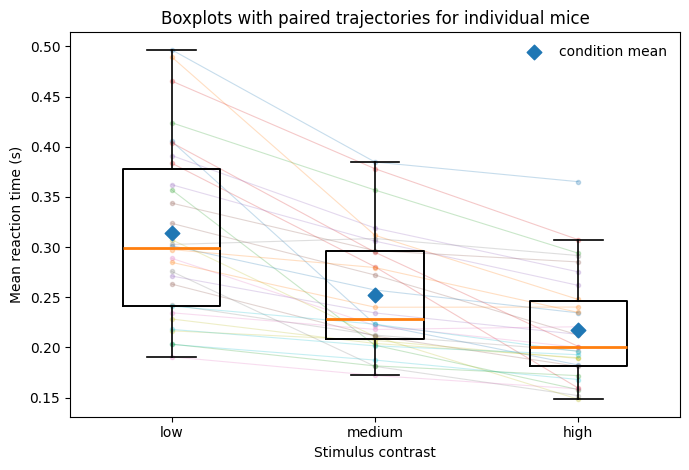

In [8]:
wide = (
    subject_means.pivot(index="subject_id", columns="contrast_level", values="mean_rt_s")
    .reindex(columns=order)
)

positions = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7, 4.8))

# Repeated-measures structure: one connected trajectory per mouse.
for _, row in wide.iterrows():
    ax.plot(
        positions, row.values,
        marker="o", markersize=3, linewidth=0.8, alpha=0.25, zorder=1
    )

# Distribution of mouse-level means in each condition.
ax.boxplot(
    [wide[level].dropna().values for level in order],
    positions=positions, widths=0.48, showfliers=False,
    medianprops={"linewidth": 2},
    boxprops={"linewidth": 1.4},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)

# Add the arithmetic mean as a diamond.
condition_mean = wide.mean()
ax.scatter(positions, condition_mean.values, marker="D", s=55,
           label="condition mean", zorder=4)

ax.set_xticks(positions, order)
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Mean reaction time (s)",
    title="Boxplots with paired trajectories for individual mice",
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Interpretation checkpoint — ⭐

Do most mouse trajectories rise, fall, or show no consistent direction as contrast increases? This descriptive pattern should be stated before looking at the p-value.


In [ ]:
trajectory_interpretation = 'Reaction time generally decreases as stimulus contrast increases.'
print(trajectory_interpretation)


## 5 · Fit the repeated-measures ANOVA

The model tests whether the three condition means are equal while preserving mouse identity. For this practical, use the standard `AnovaRM` implementation rather than calculating sums of squares manually.


In [10]:
aov = AnovaRM(
    data=subject_means,
    depvar="mean_rt_s",
    subject="subject_id",
    within=["contrast_level"],
).fit()

print(aov)
anova_table = aov.anova_table.copy()
display(anova_table)


                   Anova
               F Value Num DF  Den DF Pr > F
--------------------------------------------
contrast_level 53.1302 2.0000 58.0000 0.0000



,F Value,Num DF,Den DF,Pr > F
contrast_level,53.130217,2.0,58.0,7.743831e-14


The ANOVA p-value answers whether at least one condition differs. It does not identify which pairs differ.

We also calculate partial eta-squared as a compact effect-size summary from the reported F statistic and degrees of freedom.


In [11]:
row = anova_table.loc["contrast_level"]
F_value = float(row["F Value"])
df_effect = float(row["Num DF"])
df_error = float(row["Den DF"])
p_anova = float(row["Pr > F"])
partial_eta_squared = (F_value * df_effect) / (F_value * df_effect + df_error)

print(f"F({df_effect:.0f}, {df_error:.0f}) = {F_value:.2f}")
print(f"p = {p_anova:.3g}")
print(f"partial eta-squared = {partial_eta_squared:.3f}")


F(2, 58) = 53.13
p = 7.74e-14
partial eta-squared = 0.647


### Exercise 4 — ⭐

Complete the decision without relying only on the word “significant”:

- Is there evidence that reaction time differs across contrast levels?
- In which direction do the descriptive means change?


In [ ]:
anova_interpretation = 'There is evidence of a contrast effect, and mean reaction time becomes shorter as stimulus contrast increases.'
print(anova_interpretation)


## 6 · Paired follow-up comparisons

Because the factor is within-subject, follow-up comparisons are paired tests on mouse-level means. Holm correction controls the family-wise error rate across the three comparisons.


In [13]:
def paired_followups(wide_table, order):
    """Paired t-tests with Holm correction, paired effect size, and 95% CI."""
    rows = []
    for first, second in itertools.combinations(order, 2):
        difference = wide_table[first] - wide_table[second]
        test = stats.ttest_rel(wide_table[first], wide_table[second])
        n = difference.notna().sum()
        mean_difference = difference.mean()
        se_difference = difference.sem()
        t_critical = stats.t.ppf(0.975, df=n - 1)
        ci_low = mean_difference - t_critical * se_difference
        ci_high = mean_difference + t_critical * se_difference
        cohen_dz = mean_difference / difference.std(ddof=1)
        rows.append({
            "comparison": f"{first} - {second}",
            "mean_difference_s": mean_difference,
            "ci95_low_s": ci_low,
            "ci95_high_s": ci_high,
            "t": test.statistic,
            "df": n - 1,
            "p_raw": test.pvalue,
            "cohen_dz": cohen_dz,
        })

    results = pd.DataFrame(rows)
    results["p_holm"] = multipletests(results["p_raw"], method="holm")[1]
    results["reject_holm_0.05"] = results["p_holm"] < 0.05
    return results


In [14]:
followups = paired_followups(wide, order)
display(
    followups.style.format({
        "mean_difference_s": "{:.4f}",
        "ci95_low_s": "{:.4f}",
        "ci95_high_s": "{:.4f}",
        "t": "{:.2f}",
        "p_raw": "{:.3g}",
        "p_holm": "{:.3g}",
        "cohen_dz": "{:.2f}",
    })
)


,comparison,mean_difference_s,ci95_low_s,ci95_high_s,t,df,p_raw,cohen_dz,p_holm,reject_holm_0.05
0,low - medium,0.0614,0.0428,0.0799,6.78,29,1.92e-07,1.24,3.66e-07,True
1,low - high,0.0963,0.0704,0.1222,7.61,29,2.16e-08,1.39,6.49e-08,True
2,medium - high,0.0350,0.0245,0.0455,6.80,29,1.83e-07,1.24,3.66e-07,True


### Exercise 5 — ⭐⭐

Which comparison has the largest absolute mean difference? Use the results table rather than guessing from the p-values.


In [ ]:
largest_difference = (
    followups.assign(abs_difference=followups["mean_difference_s"].abs())
    .sort_values("abs_difference", ascending=False)
    .iloc[0]["comparison"]
)
print("Largest absolute difference:", largest_difference)


## 7 · Final result figure: boxplot with corrected significance stars

The first boxplot was deliberately descriptive: it showed the distributions and the paired mouse trajectories **before** statistical testing. After the repeated-measures ANOVA and paired follow-up tests, we can now produce the final inferential figure.

This version follows the style of the original Week 5 example:

- white boxplots summarize the mouse-level distributions;
- points represent individual mice;
- grey lines preserve the repeated-measures pairing;
- the line and error bars show the group mean ± SEM;
- brackets and stars show the **Holm-corrected paired comparisons**.

The stars must never be added from uncorrected p-values when several pairwise tests belong to the same family.


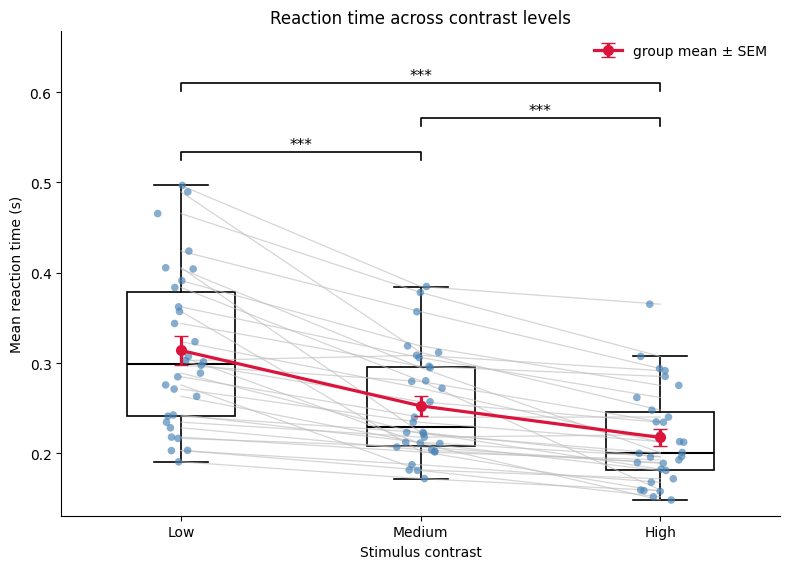

In [16]:
def p_to_stars(p_value):
    """Convert a corrected p-value to the conventional star label."""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


def add_significance_bracket(ax, x1, x2, y, height, label):
    """Draw one comparison bracket and its label."""
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y],
            linewidth=1.2, color="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + height, label,
            ha="center", va="bottom", fontsize=11)


# Put the shorter adjacent comparisons first and the widest comparison last.
plot_pairs = [("low", "medium"), ("medium", "high"), ("low", "high")]
p_holm_lookup = dict(zip(followups["comparison"], followups["p_holm"]))

positions = np.arange(len(order))
means = wide.mean().reindex(order)
sems = wide.sem().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5.8))

# Traditional boxplots of the per-mouse means.
box = ax.boxplot(
    [wide[level].dropna().values for level in order],
    positions=positions,
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 1.2},
    capprops={"color": "black", "linewidth": 1.2},
    zorder=1,
)

# Same mouse across all three conditions.
for _, row in wide.iterrows():
    ax.plot(positions, row[order].values,
            color="0.75", alpha=0.65, linewidth=0.9, zorder=2)

# Slight deterministic jitter keeps overlapping points visible.
rng = np.random.default_rng(2026)
for x, level in enumerate(order):
    values = wide[level].dropna().to_numpy()
    jitter = rng.uniform(-0.10, 0.10, size=len(values))
    ax.scatter(np.full(len(values), x) + jitter, values,
               s=30, alpha=0.65, color="steelblue", edgecolors="none", zorder=3)

# Group mean ± SEM.
ax.errorbar(
    positions, means.values, yerr=sems.values,
    fmt="o-", color="crimson", linewidth=2.3,
    capsize=5, markersize=7, label="group mean ± SEM", zorder=4,
)

# Holm-corrected pairwise significance brackets.
y_min = float(np.nanmin(wide.to_numpy()))
y_max = float(np.nanmax(wide.to_numpy()))
y_range = max(y_max - y_min, 0.05)
base = y_max + 0.08 * y_range
step = 0.11 * y_range
height = 0.025 * y_range
x_lookup = {level: i for i, level in enumerate(order)}

for bracket_index, (first, second) in enumerate(plot_pairs):
    key = f"{first} - {second}"
    corrected_p = float(p_holm_lookup[key])
    add_significance_bracket(
        ax,
        x_lookup[first], x_lookup[second],
        base + bracket_index * step,
        height,
        p_to_stars(corrected_p),
    )

ax.set_xticks(positions, [level.capitalize() for level in order])
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Mean reaction time (s)",
    title="Reaction time across contrast levels",
)
ax.set_ylim(y_min - 0.05 * y_range,
            base + len(plot_pairs) * step + 0.08 * y_range)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


**How to read the final figure**

- Blue points are the mouse-level mean reaction times.
- Grey lines connect repeated observations from the same mouse.
- The red line shows the group mean ± SEM.
- Brackets summarize paired tests after Holm correction.
- `*` means corrected *p* < .05, `**` means corrected *p* < .01, `***` means corrected *p* < .001, and `ns` means not significant.

The figure is a summary of the inferential results; the numerical ANOVA and follow-up table remain the primary statistical report.


## 8 · Write the scientific result

A useful result reports the design, test, direction, effect size, and corrected follow-ups. Avoid reporting only “p < 0.05”.

### Reporting template

> A one-factor repeated-measures ANOVA tested whether mean reaction time differed across low, medium, and high stimulus contrast. Reaction time [direction based on means]. The effect of contrast was [test result], *F*(*df*1, *df*2) = ..., *p* = ..., partial η² = .... Holm-corrected paired comparisons showed that ....


In [ ]:
result_sentence = 'A one-factor repeated-measures ANOVA showed that mean reaction time differed across low, medium, and high stimulus contrast, F(2, 58) = 53.13, p < .001, partial η² = .647. Mean reaction time decreased from low (0.314 s) to medium (0.253 s) and high contrast (0.218 s). All three Holm-corrected paired comparisons were significant, with the largest difference between low and high contrast.'
print(result_sentence)


## 9 · Optional extension — ⭐⭐⭐

Repeat the same workflow using `accuracy` instead of `mean_rt_s`. Treat this only as a teaching extension: accuracy is a proportion derived from binary trials, and trial-level generalized mixed models are preferable when the course reaches more advanced modelling.


## Take-home message

The central practical decision is not the function name. It is recognizing that the mouse is the experimental unit and that the same mouse is observed repeatedly. Prepare one value per mouse and condition, visualize the pairing, fit the repeated-measures model, and use paired corrected follow-ups.

## Data reference

The shared course data were derived from the public International Brain Laboratory behavioural release described in **“Standardized and reproducible measurement of decision-making in mice”** (International Brain Laboratory et al., 2021, *eLife*).


<a id="advanced-anova"></a>

---

# ⭐ Part II — Advanced ANOVA mechanics

> ## Advanced / optional material
>
> The following section goes beyond the core Week 5 practical.
> It examines the statistical mechanics underlying ANOVA and
> repeated-measures models in greater detail.

---


# Notebook 5B — Advanced: ANOVA mechanics, repeated-measures decomposition, and planned contrasts

**Optional companion to Week 5A**  
**Responsible TA:** Caroline · **Contributing TA:** Maël

This notebook contains the mathematical and computational depth removed from the essential practical. It is appropriate for students who want to understand how the F statistic is constructed, why pairing changes the error term, how within-subject planned contrasts should be tested, and how sphericity affects degrees of freedom.

## Learning goals

- calculate a one-way ANOVA decomposition on a small independent-groups example;
- calculate a repeated-measures decomposition on the IBL mouse means;
- quantify what is lost when pairing is ignored;
- test a planned contrast at the subject level;
- compare multiplicity corrections;
- understand the Greenhouse–Geisser correction conceptually and computationally.


## 0 · Setup and data preparation

This optional notebook uses the same **Python (qmn)** kernel and the same shared IBL file as Week 5A and the earlier course notebooks. Keep it inside the course `notebooks/` folder. No package installation or IBL download is performed here.


In [1]:
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from IPython.display import Math, display

pd.set_option("display.max_columns", 50)

# Same relative-path convention used by the earlier course notebooks.
DATA_PATH = Path("data") / "ibl_2afc.csv.gz"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find data/ibl_2afc.csv.gz. "
        "Open this notebook from the QMN course notebooks/ folder and check "
        "that the Week 1 course data were downloaded or copied correctly."
    )

print("Using the shared course dataset:", DATA_PATH.resolve())


Using the shared course dataset: /home/carolinealves/Documents/QMN-subject/QMN_course_2026_with_Week5_v2/QMN_course_2026-main/notebooks/data/ibl_2afc.csv.gz


In [2]:
def prepare_repeated_measures_table(trials):
    """Return cleaned trials and one mean RT per mouse and contrast level."""
    analysis = trials.loc[
        trials["phase"].eq("trained") &
        (~trials["no_go"]) &
        trials["reaction_time_s"].notna()
    ].copy()

    # Course-wide validity rule from the supplied data dictionary.
    analysis = analysis[analysis["reaction_time_s"].between(0.08, 2.0)]

    analysis["contrast_abs"] = analysis["signed_contrast"].abs()
    analysis = analysis[analysis["contrast_abs"] > 0].copy()

    conditions = [
        analysis["contrast_abs"] <= 0.125,
        analysis["contrast_abs"] <= 0.5,
        analysis["contrast_abs"] == 1.0,
    ]
    labels = ["low", "medium", "high"]
    analysis["contrast_level"] = np.select(conditions, labels, default=None)
    analysis = analysis.dropna(subset=["contrast_level"])

    order = ["low", "medium", "high"]
    analysis["contrast_level"] = pd.Categorical(
        analysis["contrast_level"], categories=order, ordered=True
    )

    subject_means = (
        analysis.groupby(["subject_id", "contrast_level"], observed=True)
        .agg(
            mean_rt_s=("reaction_time_s", "mean"),
            accuracy=("correct", "mean"),
            n_trials=("reaction_time_s", "size"),
        )
        .reset_index()
    )

    # AnovaRM requires a complete subject × condition table.
    complete = (
        subject_means.groupby("subject_id", observed=True)["contrast_level"]
        .nunique()
        .loc[lambda s: s == len(order)]
        .index
    )
    subject_means = subject_means[subject_means["subject_id"].isin(complete)].copy()
    return analysis, subject_means, order


In [3]:
# Load only the columns required for the advanced repeated-measures examples.
columns_needed = [
    "subject_id",
    "phase",
    "signed_contrast",
    "no_go",
    "reaction_time_s",
    "correct",
]
trials = pd.read_csv(DATA_PATH, usecols=columns_needed)

clean_trials, subject_means, order = prepare_repeated_measures_table(trials)
wide = (
    subject_means.pivot(index="subject_id", columns="contrast_level", values="mean_rt_s")
    .reindex(columns=order)
)
print("Repeated-measures matrix shape:", wide.shape)
display(wide.head())


Repeated-measures matrix shape: (30, 3)


contrast_level,low,medium,high
subject_id,,,
CSHL045,0.405504,0.223112,0.182417
CSHL046,0.489543,0.311712,0.247756
CSHL047,0.357088,0.202142,0.157890
CSHL049,0.383629,0.280288,0.159340
CSHL051,0.271123,0.234311,0.212919


## 1 · One-way ANOVA decomposition on independent groups

We begin with a deliberately small synthetic example where observations belong to three independent groups. This avoids confusing the classical one-way formula with the repeated-measures IBL design.

### Hypotheses

$$
H_0:\mu_1=\mu_2=\cdots=\mu_k
\qquad\text{versus}\qquad
H_1:\text{at least one group mean differs.}
$$

### Sum-of-squares decomposition

For group $i=1,\ldots,k$ and observation $j=1,\ldots,n_i$:

$$
SS_{\mathrm{between}}
=\sum_{i=1}^{k}n_i(\bar y_i-\bar y)^2,
$$

$$
SS_{\mathrm{within}}
=\sum_{i=1}^{k}\sum_{j=1}^{n_i}(y_{ij}-\bar y_i)^2,
$$

$$
SS_{\mathrm{total}}
=\sum_{i=1}^{k}\sum_{j=1}^{n_i}(y_{ij}-\bar y)^2
=SS_{\mathrm{between}}+SS_{\mathrm{within}}.
$$

The corresponding mean squares and F ratio are

$$
MS_{\mathrm{between}}=\frac{SS_{\mathrm{between}}}{k-1},
\qquad
MS_{\mathrm{within}}=\frac{SS_{\mathrm{within}}}{N-k},
$$

$$
F=\frac{MS_{\mathrm{between}}}{MS_{\mathrm{within}}}.
$$

A large F means that separation among group means is large relative to the variation remaining inside the groups.


In [4]:
group_a = np.array([4.1, 4.4, 4.0, 4.5, 4.2, 4.3])
group_b = np.array([4.8, 5.0, 4.9, 5.1, 4.7, 5.2])
group_c = np.array([5.5, 5.7, 5.6, 5.9, 5.4, 5.8])
groups = [group_a, group_b, group_c]

all_values = np.concatenate(groups)
grand_mean = all_values.mean()
k = len(groups)
N = len(all_values)

ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)
ss_total = ((all_values - grand_mean) ** 2).sum()

df_between = k - 1
df_within = N - k
ms_between = ss_between / df_between
ms_within = ss_within / df_within
F_manual = ms_between / ms_within
p_manual = stats.f.sf(F_manual, df_between, df_within)

print(f"SS_between = {ss_between:.3f}")
print(f"SS_within  = {ss_within:.3f}")
print(f"SS_total   = {ss_total:.3f}")
print(f"Identity check: {ss_between + ss_within:.3f}")
print(f"F({df_between}, {df_within}) = {F_manual:.3f}, p = {p_manual:.3g}")


SS_between = 5.880
SS_within  = 0.525
SS_total   = 6.405
Identity check: 6.405
F(2, 15) = 84.000, p = 7.12e-09


<IPython.core.display.Math object>

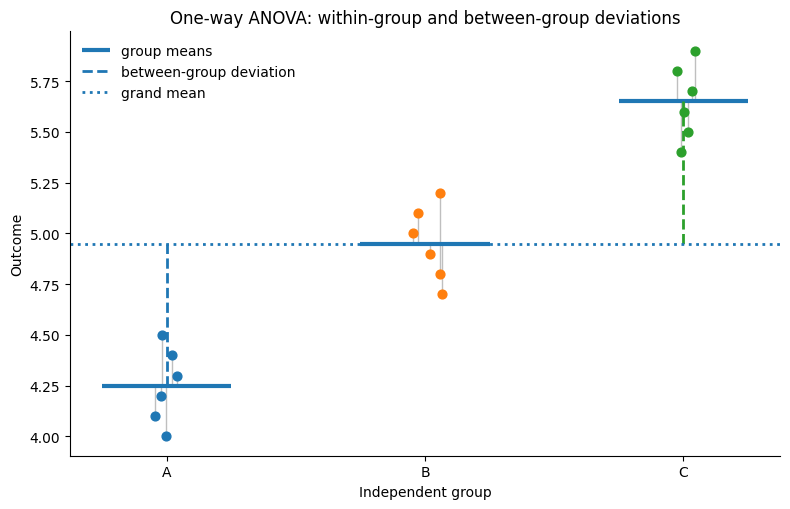

In [5]:
# Render the numerical substitution into the F-ratio formula.
display(Math(
    rf"F=\frac{{MS_{{\mathrm{{between}}}}}}{{MS_{{\mathrm{{within}}}}}}"
    rf"=\frac{{{ms_between:.3f}}}{{{ms_within:.3f}}}={F_manual:.3f}"
))

# Visualize which deviations contribute to the two sums of squares.
fig, ax = plt.subplots(figsize=(8, 5.2))
rng = np.random.default_rng(2026)
labels = ["A", "B", "C"]

for x, (label, values) in enumerate(zip(labels, groups)):
    jitter = rng.uniform(-0.07, 0.07, len(values))
    group_mean = values.mean()

    # Within-group deviations: each observation to its own group mean.
    for xj, value in zip(np.full(len(values), x) + jitter, values):
        ax.plot([xj, xj], [value, group_mean], color="0.75", linewidth=1)
    ax.scatter(np.full(len(values), x) + jitter, values, s=40, zorder=3)
    ax.hlines(group_mean, x - 0.25, x + 0.25, linewidth=3,
              label="group means" if x == 0 else None)

    # Between-group deviation: each group mean to the grand mean.
    ax.plot([x, x], [group_mean, grand_mean], linestyle="--", linewidth=2,
            label="between-group deviation" if x == 0 else None)

ax.axhline(grand_mean, linestyle=":", linewidth=2, label="grand mean")
ax.set_xticks(range(len(labels)), labels)
ax.set(
    xlabel="Independent group",
    ylabel="Outcome",
    title="One-way ANOVA: within-group and between-group deviations",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [6]:
check = stats.f_oneway(*groups)
print("SciPy check:", check)
assert np.isclose(F_manual, check.statistic)
assert np.isclose(p_manual, check.pvalue)


SciPy check: F_onewayResult(statistic=np.float64(83.99999999999996), pvalue=np.float64(7.117070533984376e-09))


### Exercise 1 — ⭐⭐

Increase only the within-group spread while leaving the approximate group means unchanged. What happens to F, and why?


In [ ]:
# One possible demonstration:
noisier_groups = [
    np.array([3.3, 5.2, 3.8, 5.0, 4.0, 4.5]),
    np.array([3.8, 6.0, 4.1, 5.8, 4.5, 5.2]),
    np.array([4.4, 6.8, 4.8, 6.5, 5.0, 6.1]),
]
print(stats.f_oneway(*noisier_groups))


## 2 · Repeated-measures decomposition

For the IBL table, each row of `wide` is a mouse and each column is a contrast condition. A score from mouse $i$ in condition $j$ can be written conceptually as

$$
y_{ij}=\bar y+\underbrace{(\bar y_{\cdot j}-\bar y)}_{\text{condition effect}}
+\underbrace{(\bar y_{i\cdot}-\bar y)}_{\text{mouse baseline}}
+\underbrace{e_{ij}}_{\text{residual}}.
$$

The total variability is partitioned into condition, stable between-mouse, and residual components:

$$
SS_{\mathrm{subject}}
=k\sum_{i=1}^{n}(\bar y_{i\cdot}-\bar y)^2,
$$

$$
SS_{\mathrm{condition}}
=n\sum_{j=1}^{k}(\bar y_{\cdot j}-\bar y)^2,
$$

$$
SS_{\mathrm{error}}
=SS_{\mathrm{total}}-SS_{\mathrm{subject}}-SS_{\mathrm{condition}}.
$$

The repeated-measures F ratio is

$$
F=\frac{MS_{\mathrm{condition}}}{MS_{\mathrm{error}}}
=\frac{SS_{\mathrm{condition}}/(k-1)}
{SS_{\mathrm{error}}/[(k-1)(n-1)]}.
$$

The essential advantage of pairing is that stable mouse-to-mouse variation is removed from the denominator instead of being counted as unexplained noise.


In [8]:
Y = wide.to_numpy()
n_subjects, n_conditions = Y.shape
grand = Y.mean()
subject_mean = Y.mean(axis=1)
condition_mean = Y.mean(axis=0)

ss_subject = n_conditions * ((subject_mean - grand) ** 2).sum()
ss_condition = n_subjects * ((condition_mean - grand) ** 2).sum()
ss_total_rm = ((Y - grand) ** 2).sum()
ss_error = ss_total_rm - ss_subject - ss_condition

df_condition = n_conditions - 1
df_error = (n_conditions - 1) * (n_subjects - 1)
ms_condition = ss_condition / df_condition
ms_error = ss_error / df_error
F_rm = ms_condition / ms_error
p_rm = stats.f.sf(F_rm, df_condition, df_error)
partial_eta2 = ss_condition / (ss_condition + ss_error)

rm_table = pd.DataFrame({
    "source": ["subjects", "contrast", "error", "total"],
    "SS": [ss_subject, ss_condition, ss_error, ss_total_rm],
    "df": [n_subjects - 1, df_condition, df_error, n_subjects*n_conditions - 1],
})
display(rm_table)
print(f"F({df_condition}, {df_error}) = {F_rm:.3f}, p = {p_rm:.3g}")
print(f"partial eta-squared = {partial_eta2:.3f}")
print("Identity check:", np.isclose(ss_subject + ss_condition + ss_error, ss_total_rm))


,source,SS,df
0,subjects,0.331445,29
1,contrast,0.142685,2
2,error,0.077882,58
3,total,0.552012,89


F(2, 58) = 53.130, p = 7.74e-14
partial eta-squared = 0.647
Identity check: True


<IPython.core.display.Math object>

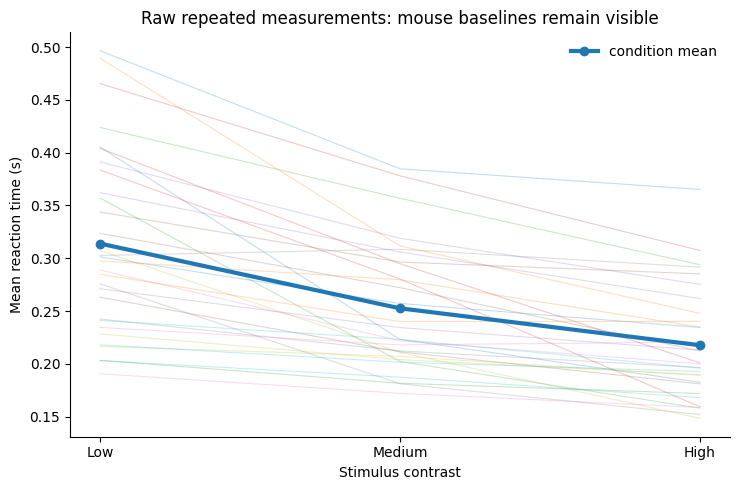

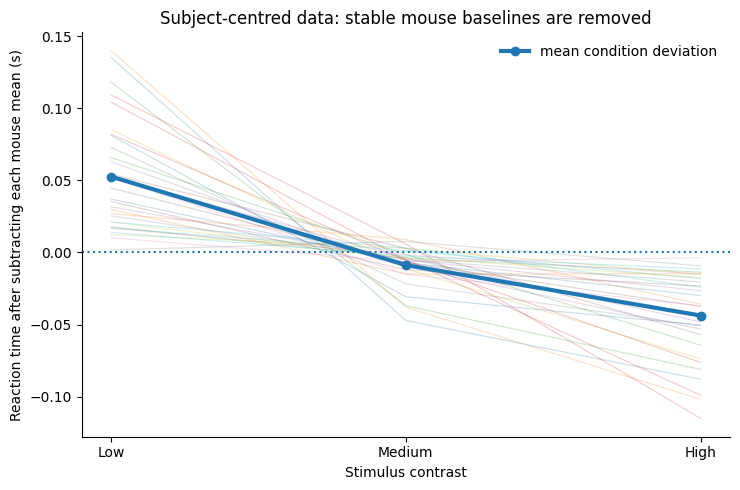

In [9]:
# Render the repeated-measures F formula with the observed mean squares.
display(Math(
    rf"F=\frac{{MS_{{\mathrm{{condition}}}}}}{{MS_{{\mathrm{{error}}}}}}"
    rf"=\frac{{{ms_condition:.6f}}}{{{ms_error:.6f}}}={F_rm:.3f}"
))

# Plot 1: raw repeated measurements, where different mouse baselines are visible.
positions = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.5, 5))
for _, row in wide.iterrows():
    ax.plot(positions, row[order].values, alpha=0.25, linewidth=0.8)
ax.plot(positions, condition_mean, marker="o", linewidth=3,
        label="condition mean")
ax.set_xticks(positions, [level.capitalize() for level in order])
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Mean reaction time (s)",
    title="Raw repeated measurements: mouse baselines remain visible",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Plot 2: subtract each mouse's own mean to visualize baseline removal.
subject_centered = wide.sub(wide.mean(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7.5, 5))
for _, row in subject_centered.iterrows():
    ax.plot(positions, row[order].values, alpha=0.25, linewidth=0.8)
ax.plot(positions, subject_centered.mean(axis=0).reindex(order),
        marker="o", linewidth=3, label="mean condition deviation")
ax.axhline(0, linestyle=":", linewidth=1.5)
ax.set_xticks(positions, [level.capitalize() for level in order])
ax.set(
    xlabel="Stimulus contrast",
    ylabel="Reaction time after subtracting each mouse mean (s)",
    title="Subject-centred data: stable mouse baselines are removed",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [10]:
rm_long = wide.reset_index().melt(
    id_vars="subject_id", var_name="contrast_level", value_name="mean_rt_s"
)
software_result = AnovaRM(
    rm_long, depvar="mean_rt_s", subject="subject_id", within=["contrast_level"]
).fit()
print(software_result)


                   Anova
               F Value Num DF  Den DF Pr > F
--------------------------------------------
contrast_level 53.1302 2.0000 58.0000 0.0000



### Exercise 2 — ⭐⭐

Calculate the percentage of total variability attributable to stable between-mouse differences. This percentage is descriptive, not the partial eta-squared for the condition effect.


In [11]:
between_mouse_percentage = 100 * ss_subject / ss_total_rm
print(f"Between-mouse share of total variability: {between_mouse_percentage:.1f}%")


Between-mouse share of total variability: 60.0%


## 3 · What happens when pairing is ignored?

The next calculation uses the same 90 mouse-condition means but incorrectly treats the three columns as independent groups. It is shown only to diagnose the consequence of discarding mouse identity; it is not the analysis to report.


In [12]:
naive = stats.f_oneway(*(wide[level] for level in order))
comparison = pd.DataFrame({
    "analysis": ["Repeated measures", "Pairing ignored"],
    "F": [F_rm, naive.statistic],
    "p": [p_rm, naive.pvalue],
})
display(comparison)


,analysis,F,p
0,Repeated measures,53.130217,7.743831e-14
1,Pairing ignored,15.163431,2.240259e-06


### Interpretation

Both calculations may detect the large contrast effect, but the repeated-measures model gives the correct denominator because stable differences among mice are not treated as unexplained noise.


## 4 · Planned contrasts for a within-subject design

A planned contrast is a scientific hypothesis encoded by weights chosen before examining the outcome. For condition means $\mu_j$ and weights $c_j$ satisfying $\sum_j c_j=0$,

$$
L=\sum_{j=1}^{k}c_j\mu_j.
$$

In a repeated-measures design, calculate one contrast score for each mouse,

$$
L_i=\sum_{j=1}^{k}c_j y_{ij},
$$

and test the mouse-level scores against zero. This preserves the paired design.

Here the pre-planned comparison asks whether high-contrast reaction time differs from the average of low and medium contrast. Using weights $(0.5,\,0.5,\,-1)$,

$$
L_i=0.5y_{i,\mathrm{low}}+0.5y_{i,\mathrm{medium}}-y_{i,\mathrm{high}}.
$$

Positive values mean that the average reaction time in the lower-contrast conditions is longer than reaction time at high contrast.


In [13]:
# Positive values mean low/medium RT is longer than high-contrast RT.
contrast_score = 0.5 * wide["low"] + 0.5 * wide["medium"] - wide["high"]
contrast_test = stats.ttest_1samp(contrast_score, popmean=0)

n = contrast_score.size
mean_contrast = contrast_score.mean()
se_contrast = contrast_score.sem()
t_critical = stats.t.ppf(0.975, df=n-1)
ci = (
    mean_contrast - t_critical * se_contrast,
    mean_contrast + t_critical * se_contrast,
)
cohen_dz = mean_contrast / contrast_score.std(ddof=1)

print(f"Mean planned contrast = {mean_contrast:.4f} s")
print(f"t({n-1}) = {contrast_test.statistic:.2f}, p = {contrast_test.pvalue:.3g}")
print(f"95% CI = [{ci[0]:.4f}, {ci[1]:.4f}] s")
print(f"Cohen's dz = {cohen_dz:.2f}")


display(Math(r"L_i=0.5y_{i,\mathrm{low}}+0.5y_{i,\mathrm{medium}}-y_{i,\mathrm{high}}"))


Mean planned contrast = 0.0657 s
t(29) = 7.69, p = 1.76e-08
95% CI = [0.0482, 0.0831] s
Cohen's dz = 1.40


<IPython.core.display.Math object>

### Exercise 3 — ⭐⭐

Define and test the pre-planned linear trend with weights `[-1, 0, 1]` for low, medium, and high. State what the sign means for reaction time.


In [ ]:
linear_trend_score = -1 * wide["low"] + 0 * wide["medium"] + 1 * wide["high"]
linear_trend_test = stats.ttest_1samp(linear_trend_score, 0)
print(linear_trend_test)
print("A negative mean score indicates shorter RT at high than low contrast.")


## 5 · Post-hoc tests and multiplicity

Planned contrasts and exploratory pairwise comparisons answer different questions. The exploratory family below contains three paired tests.


In [15]:
def paired_followups(wide_table, order):
    """Paired t-tests with Holm correction, paired effect size, and 95% CI."""
    rows = []
    for first, second in itertools.combinations(order, 2):
        difference = wide_table[first] - wide_table[second]
        test = stats.ttest_rel(wide_table[first], wide_table[second])
        n = difference.notna().sum()
        mean_difference = difference.mean()
        se_difference = difference.sem()
        t_critical = stats.t.ppf(0.975, df=n - 1)
        ci_low = mean_difference - t_critical * se_difference
        ci_high = mean_difference + t_critical * se_difference
        cohen_dz = mean_difference / difference.std(ddof=1)
        rows.append({
            "comparison": f"{first} - {second}",
            "mean_difference_s": mean_difference,
            "ci95_low_s": ci_low,
            "ci95_high_s": ci_high,
            "t": test.statistic,
            "df": n - 1,
            "p_raw": test.pvalue,
            "cohen_dz": cohen_dz,
        })

    results = pd.DataFrame(rows)
    results["p_holm"] = multipletests(results["p_raw"], method="holm")[1]
    results["reject_holm_0.05"] = results["p_holm"] < 0.05
    return results


In [16]:
followups = paired_followups(wide, order)

for method in ["bonferroni", "holm", "fdr_bh"]:
    followups[f"p_{method}"] = multipletests(followups["p_raw"], method=method)[1]

display(followups)


,comparison,mean_difference_s,ci95_low_s,ci95_high_s,t,df,p_raw,cohen_dz,p_holm,reject_holm_0.05,p_bonferroni,p_fdr_bh
0,low - medium,0.061352,0.042846,0.079857,6.780673,29,1.918704e-07,1.237976,3.658377e-07,True,5.756111e-07,1.918704e-07
1,low - high,0.096336,0.070448,0.122223,7.610996,29,2.164592e-08,1.389571,6.493777e-08,True,6.493777e-08,6.493777e-08
2,medium - high,0.034984,0.024460,0.045509,6.798546,29,1.829189e-07,1.241239,3.658377e-07,True,5.487566e-07,1.918704e-07


### Exercise 4 — ⭐⭐

Construct three hypothetical raw p-values near 0.05 for which Bonferroni, Holm, and Benjamini–Hochberg give different rejection patterns. Do not search the real data for such an example.


In [17]:
demo_p = np.array([0.012, 0.028, 0.049])
for method in ["bonferroni", "holm", "fdr_bh"]:
    adjusted = multipletests(demo_p, method=method)[1]
    print(method, np.round(adjusted, 4), adjusted < 0.05)


bonferroni [0.036 0.084 0.147] [ True False False]
holm [0.036 0.056 0.056] [ True False False]
fdr_bh [0.036 0.042 0.049] [ True  True  True]


## 6 · Sphericity and the Greenhouse–Geisser correction

With three or more repeated conditions, the usual F test assumes that the variances of all pairwise difference scores are equal. This is the sphericity assumption.

For a centred covariance matrix $\mathbf{S}_c$, Greenhouse–Geisser epsilon is

$$
\hat\epsilon_{GG}
=\frac{[\operatorname{tr}(\mathbf{S}_c)]^2}
{(k-1)\operatorname{tr}(\mathbf{S}_c^2)}.
$$

Its range is

$$
\frac{1}{k-1}\leq \hat\epsilon_{GG}\leq 1.
$$

The F statistic remains unchanged, but the degrees of freedom are multiplied by epsilon:

$$
df_1^*=\hat\epsilon_{GG}(k-1),
\qquad
df_2^*=\hat\epsilon_{GG}(k-1)(n-1).
$$

Values near 1 imply little correction. Smaller values reduce the degrees of freedom and produce a more conservative p-value. This diagnostic is advanced material and is not required in Week 5A.


In [18]:
covariance = np.cov(Y, rowvar=False, ddof=1)
centering = np.eye(n_conditions) - np.ones((n_conditions, n_conditions)) / n_conditions
centered_covariance = centering @ covariance @ centering

epsilon_gg = (
    np.trace(centered_covariance) ** 2
    / ((n_conditions - 1) * np.trace(centered_covariance @ centered_covariance))
)

df_condition_gg = epsilon_gg * df_condition
df_error_gg = epsilon_gg * df_error
p_gg = stats.f.sf(F_rm, df_condition_gg, df_error_gg)

print(f"Greenhouse-Geisser epsilon = {epsilon_gg:.3f}")
print(f"Uncorrected p = {p_rm:.3g}")
print(f"GG-corrected dfs = ({df_condition_gg:.3f}, {df_error_gg:.3f})")
print(f"GG-corrected p = {p_gg:.3g}")


display(Math(rf"\hat{{\epsilon}}_{{GG}}={epsilon_gg:.3f},\quad df_1^*={df_condition_gg:.3f},\quad df_2^*={df_error_gg:.3f}"))


Greenhouse-Geisser epsilon = 0.571
Uncorrected p = 7.74e-14
GG-corrected dfs = (1.142, 33.120)
GG-corrected p = 7.41e-09


<IPython.core.display.Math object>

### Exercise 5 — ⭐⭐⭐

Calculate the three variances of the paired difference scores (`low-medium`, `low-high`, `medium-high`). Explain how unequal difference-score variances relate to sphericity.


In [19]:
difference_variances = {
    "low-medium": (wide["low"] - wide["medium"]).var(ddof=1),
    "low-high": (wide["low"] - wide["high"]).var(ddof=1),
    "medium-high": (wide["medium"] - wide["high"]).var(ddof=1),
}
print(pd.Series(difference_variances))


low-medium     0.002456
low-high       0.004806
medium-high    0.000794
dtype: float64


## 7 · Research hygiene simulation

Optional stopping changes the long-run false-positive rate even when each individual test is valid. The simulation compares one pre-planned test with repeatedly checking the p-value and stopping after the first result below 0.05.


In [20]:
def false_positive_rate(strategy, simulations=300, n_max=150, seed=2026):
    rng = np.random.default_rng(seed)
    false_positives = 0
    for _ in range(simulations):
        first = rng.normal(size=n_max)
        second = rng.normal(size=n_max)
        if strategy == "single_test":
            false_positives += stats.ttest_ind(first, second).pvalue < 0.05
        elif strategy == "optional_stopping":
            detected = any(
                stats.ttest_ind(first[:n], second[:n]).pvalue < 0.05
                for n in range(20, n_max + 1, 5)
            )
            false_positives += detected
        else:
            raise ValueError("Unknown strategy")
    return false_positives / simulations

print("Single pre-planned test:", false_positive_rate("single_test"))
print("Optional stopping:", false_positive_rate("optional_stopping"))


Single pre-planned test: 0.03333333333333333
Optional stopping: 0.21


## Final synthesis

- One-way ANOVA and repeated-measures ANOVA use related F-ratio logic but different error structures.
- The independent experimental unit must determine the inferential table.
- Within-subject planned contrasts are tested using one contrast score per subject.
- Pairwise post-hoc tests remain paired and require a pre-specified multiplicity strategy.
- With three or more repeated conditions, sphericity and corrected degrees of freedom deserve attention.

## Data reference

The shared course data were derived from the public International Brain Laboratory behavioural release described in **“Standardized and reproducible measurement of decision-making in mice”** (International Brain Laboratory et al., 2021, *eLife*).
